11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.8717 - loss: 0.4697 - val_accuracy: 0.9773 - val_loss: 0.0817
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.9767 - loss: 0.0800 - val_accuracy: 0.9838 - val_loss: 0.0598
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.9848 - loss: 0.0512 - val_accuracy: 0.9868 - val_loss: 0.0524
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9886 - loss: 0.0370 - val_accuracy: 0.9827 - val_loss: 0.0628
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9910 - loss: 0.0292 - val_accuracy: 0.9857 - val_loss: 0.0476
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9841 - loss: 0.0501

Test accuracy: 0.9869
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


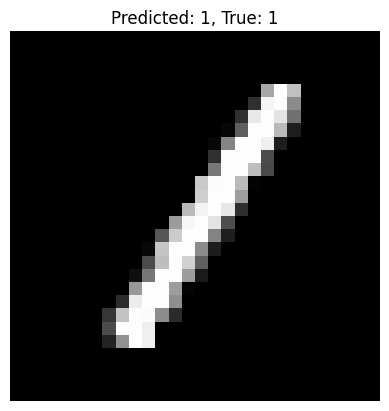

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train_cat, epochs=5, batch_size=128, validation_split=0.1)
loss, accuracy = model.evaluate(x_test, y_test_cat)
print(f"\nTest accuracy: {accuracy:.4f}")
index = np.random.randint(0, x_test.shape[0])
image = x_test[index]
true_label = y_test[index]
prediction = model.predict(np.expand_dims(image, axis=0))
predicted_label = np.argmax(prediction)
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_label}, True: {true_label}")
plt.axis('off')
plt.show()
